In [ ]:
#PROBLEM STATEMENT: Can a machine automatically sort football players into meaningful types, without being told what the types are?

In [8]:
import pandas as pd
import numpy as np

In [9]:
players = pd.read_csv("C:/Users/PAJEET/Documents/Jupyter codes/Data Files/archive/players_22.csv")

C:\Users\PAJEET\AppData\Local\Temp\ipykernel_4948\3306515252.py:1: DtypeWarning: Columns (25,108) have mixed types. Specify dtype option on import or set low_memory=False.
  players = pd.read_csv("C:/Users/PAJEET/Documents/Jupyter codes/Data Files/archive/players_22.csv")


In [10]:
players

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,"RW, ST, CF",93,93,78000000.0,320000.0,34,...,50+3,50+3,50+3,61+3,19+3,https://cdn.sofifa.net/players/158/023/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,ST,92,92,119500000.0,270000.0,32,...,60+3,60+3,60+3,61+3,19+3,https://cdn.sofifa.net/players/188/545/22_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1353/60.png,https://cdn.sofifa.net/flags/pl.png
2,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"ST, LW",91,91,45000000.0,270000.0,36,...,53+3,53+3,53+3,60+3,20+3,https://cdn.sofifa.net/players/020/801/22_120.png,https://cdn.sofifa.net/teams/11/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png
3,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,"LW, CAM",91,91,129000000.0,270000.0,29,...,50+3,50+3,50+3,62+3,20+3,https://cdn.sofifa.net/players/190/871/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,NaN,https://cdn.sofifa.net/flags/br.png
4,192985,https://sofifa.com/player/192985/kevin-de-bruy...,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,125500000.0,350000.0,30,...,69+3,69+3,69+3,75+3,21+3,https://cdn.sofifa.net/players/192/985/22_120.png,https://cdn.sofifa.net/teams/10/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1325/60.png,https://cdn.sofifa.net/flags/be.png
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19234,261962,https://sofifa.com/player/261962/defu-song/220002,Song Defu,宋德福,CDM,47,52,70000.0,1000.0,22,...,46+2,46+2,46+2,48+2,15+2,https://cdn.sofifa.net/players/261/962/22_120.png,https://cdn.sofifa.net/teams/112541/60.png,https://cdn.sofifa.net/flags/cn.png,NaN,https://cdn.sofifa.net/flags/cn.png
19235,262040,https://sofifa.com/player/262040/caoimhin-port...,C. Porter,Caoimhin Porter,CM,47,59,110000.0,500.0,19,...,44+2,44+2,44+2,48+2,14+2,https://cdn.sofifa.net/players/262/040/22_120.png,https://cdn.sofifa.net/teams/445/60.png,https://cdn.sofifa.net/flags/ie.png,NaN,https://cdn.sofifa.net/flags/ie.png
19236,262760,https://sofifa.com/player/262760/nathan-logue/...,N. Logue,Nathan Logue-Cunningham,CM,47,55,100000.0,500.0,21,...,45+2,45+2,45+2,47+2,12+2,https://cdn.sofifa.net/players/262/760/22_120.png,https://cdn.sofifa.net/teams/111131/60.png,https://cdn.sofifa.net/flags/ie.png,NaN,https://cdn.sofifa.net/flags/ie.png
19237,262820,https://sofifa.com/player/262820/luke-rudden/2...,L. Rudden,Luke Rudden,ST,47,60,110000.0,500.0,19,...,26+2,26+2,26+2,32+2,15+2,https://cdn.sofifa.net/players/262/820/22_120.png,https://cdn.sofifa.net/teams/111131/60.png,https://cdn.sofifa.net/flags/ie.png,NaN,https://cdn.sofifa.net/flags/ie.png


In [ ]:
#This 5 features answer one question: what is this player worth, now and in the future?

#Overall — what he can do right now
#Potential — what he will be able to do later
#Value — what the market says he is worth
#Wage — what a club is actually paying for him
#Age — how much time he has left to reach that potential
#Together they describe a player's career stage and market position.
#That is why they cluster cleanly. A 19-year-old with 72 overall and 88 potential looks completely different from a 31-year-old with 88 overall and 88 potential, even though the ratings match. The age, wage, and value separate them into the right buckets.
#Features like pace, dribbling, or shooting were ignored because they describe playing style, not career stage. Mixing those in would blur the clusters — you would get "fast young players in one cluster" instead of "elite players vs prospects vs squad fillers."


In [11]:
features = ["overall", "potential", "wage_eur", "value_eur", "age" ]

In [12]:
players = players.dropna(subset=features)

In [13]:
data = players[features].copy()

In [14]:
data

,overall,potential,wage_eur,value_eur,age
0,93,93,320000.0,78000000.0,34
1,92,92,270000.0,119500000.0,32
2,91,91,270000.0,45000000.0,36
3,91,91,270000.0,129000000.0,29
4,91,91,350000.0,125500000.0,30
...,...,...,...,...,...
19234,47,52,1000.0,70000.0,22
19235,47,59,500.0,110000.0,19
19236,47,55,500.0,100000.0,21
19237,47,60,500.0,110000.0,19


In [15]:
#K-Means measures distance between points.
#Wage can be €200,000. Age is 24. Overall is 87.
#Without scaling, the wage number dominates completely. The distance between two players is almost entirely decided by wage difference. Age and overall become invisible — they are too small to matter.
#Min-max scaling squashes every feature into the same range (1 to 10 in your code). Now a big difference in age counts the same as a big difference in wage.
#Every feature gets an equal vote in deciding who is close to who.
#Without it, you are not clustering on all 5 features. You are clustering on wage, with noise. 



In [16]:
data = ((data - data.min()) / (data.max() - data.min())) * 9 + 1

In [17]:
data.describe()

,overall,potential,wage_eur,value_eur,age
count,19165.000000,19165.000000,19165.000000,19165.000000,19165.000000
mean,4.670472,5.319998,1.219443,1.131826,4.063345
std,1.346635,1.191076,0.501528,0.353229,1.575838
min,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.739130,4.521739,1.012876,1.021620,2.666667
50%,4.717391,5.304348,1.064378,1.044817,4.000000
75%,5.500000,6.086957,1.193133,1.092370,5.333333
max,10.000000,10.000000,10.000000,10.000000,10.000000


In [18]:
data.head()

,overall,potential,wage_eur,value_eur,age
0,10.000000,9.608696,9.227468,4.618307,7.000000
1,9.804348,9.413043,7.939914,6.543654,6.333333
2,9.608696,9.217391,7.939914,3.087308,7.666667
3,9.608696,9.217391,7.939914,6.984396,5.333333
4,9.608696,9.217391,10.000000,6.822018,5.666667


In [19]:
#K-Means from Scratch
#sklearn can do this in two lines. I did not start there.
#Implementing it manually forced me to understand what actually happens at each step: how centroids are initialized, how each player gets assigned to the nearest centroid, how centroids shift after each assignment, and when the algorithm decides it is done.
#The sklearn implementation at the end confirms my logic produces the same result.


In [20]:
def random_centriods(data, k):
    centriods = []
    for i in range(k):
        centriod = data.apply(lambda x: float(x.sample()))
        centriods.append(centriod)
    return pd.concat(centriods, axis=1)

In [21]:
centriods = random_centriods(data, 5)

C:\Users\PAJEET\AppData\Local\Temp\ipykernel_4948\286709010.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  centriod = data.apply(lambda x: float(x.sample()))


In [22]:
centriods

,0,1,2,3,4
overall,5.108696,4.717391,4.130435,4.326087,3.543478
potential,4.913043,6.086957,4.913043,6.478261,4.717391
wage_eur,1.218884,1.000000,1.064378,1.064378,1.038627
value_eur,1.672294,1.055255,1.027419,1.014660,1.025099
age,3.000000,7.000000,6.000000,6.666667,2.666667


In [23]:
def get_labels(data, centriods):
    distances = centriods.apply(lambda x: np.sqrt(((data - x) ** 2).sum(axis=1)))
    return distances.idxmin(axis=1)

In [24]:
labels = get_labels(data, centriods)

In [25]:
labels.value_counts()

0    6226
4    6071
2    4800
1    2059
3       9
Name: count, dtype: int64

In [26]:
def new_centriods(data, labels, k):
    return data.groupby(labels).apply(lambda x: np.exp(np.log(x).mean())).T

In [27]:
#Validation Against sklearn
#The manual implementation works, but trust needs to be earned.
#Running sklearn's KMeans on the same data with the same k produces cluster centers that match. Same groupings, same structure.
#This confirms the manual logic was correct — not approximately correct, but correct enough that an industry-standard library agrees with it.

In [28]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from IPython.display import clear_output

In [29]:
def plot_cluster(data, labels, centriods, iteration):
    pca = PCA(n_components=2)
    data_2d = pca.fit_transform(data)
    centriods_2d = pca.transform(centriods.T)
    clear_output(wait=True)
    plt.title(f'Iteration {iteration}')
    plt.scatter(x=data_2d[:,0], y=data_2d[:,1], c=labels)
    plt.scatter(x=centriods_2d[:,0], y=centriods_2d[:,1])
    plt.show()
    

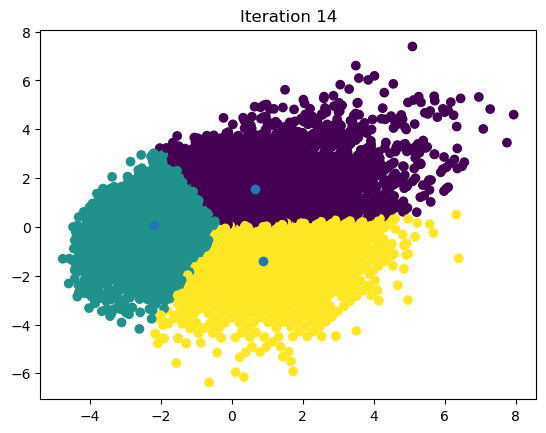

In [ ]:
max_iteration = 100
k = 3

centriods = random_centriods(data, k)
old_centriods = pd.DataFrame()
iteration = 1

while iteration < max_iteration and not centriods.equals(old_centriods):
    old_centriods = centriods

    labels = get_labels(data, centriods)
    centriods = new_centriods(data, labels, k)
    plot_cluster(data, labels, centriods,  iteration)
    iteration += 1

In [ ]:
players[labels ==0][["short_name"] + feartures]

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
kmeans = KMeans(3)
kmeans.fit(data)

In [ ]:
centriods = kmeans.cluster_centers_

In [ ]:
pd.DataFrame(centriods, columns=features).T

In [ ]:
centriods

In [2]:
players['cluster'] = labels.values
cluster_summary = players.groupby('cluster')[features + ['short_name']].agg({
    'overall': 'mean',
    'potential': 'mean', 
    'wage_eur': 'mean',
    'value_eur': 'mean',
    'age': 'mean',
    'short_name': 'count'
}).rename(columns={'short_name': 'player_count'})
print(cluster_summary.round(2))

NameError: name 'label' is not defined